# Stage-2 MALA-within-Gibbs posterior diagnostics: Chain 1

This notebook analyzes the **completed longer Chain 1 run** stored as
`stage2_multichain/chain_00`. It reads saved arrays only: it does not import JAX,
train the DDPM, run MCMC, or require a GPU.

The goal is to assess computational integrity, mixing, tuning, and posterior
summaries of the terminal mean parameter. Because only one independent chain
completed, the notebook uses cautious language, does not report multi-chain
$\hat R$, and does not claim convergence from this chain alone.

In [1]:
from pathlib import Path
from html import escape
import json

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, HTML, display

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.figsize": (10, 5), "figure.dpi": 120,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titleweight": "bold", "font.size": 10,
})
COLORS = {"blue": "#2563A6", "orange": "#DD7F2A", "green": "#2A9D78",
          "red": "#C74B50", "purple": "#7857A6", "gray": "#667085"}

# Locate the completed experiment from either the repository root or analysis/.
RUN = next((p for p in [Path("runs/two_stage_mnist_t100"),
                        Path("../runs/two_stage_mnist_t100")]
            if p.is_dir()), None)
if RUN is None:
    raise FileNotFoundError("Cannot find runs/two_stage_mnist_t100.")

# Chain 1 is Slurm array task 0 and is stored as chain_00.
CHAIN = RUN / "stage2_multichain" / "chain_00"
if not (CHAIN / "completed.json").is_file():
    raise FileNotFoundError(f"Completed Chain 1 outputs not found: {CHAIN}")

def read_json(path):
    return json.loads(path.read_text())

# Shared experiment metadata and Chain-1-specific output.
experiment = read_json(RUN / "experiment.json")
stage1 = read_json(RUN / "stage1" / "completed.json")
schedule_summary = read_json(RUN / "schedule_summary.json")
config = read_json(CHAIN / "config.json")
completion = read_json(CHAIN / "completed.json")
checkpoint_meta = {
    "sweep": completion["sweep"],
    "completion_record": completion,
}
posterior_file = np.load(CHAIN / "posterior_samples.npz", allow_pickle=False)
diagnostics_file = np.load(CHAIN / "diagnostics.npz", allow_pickle=False)

# Copy these arrays into memory, then close the NPZ file handles.
posterior = {name: posterior_file[name] for name in posterior_file.files}
diagnostics = {name: diagnostics_file[name] for name in diagnostics_file.files}
posterior_file.close(); diagnostics_file.close()

def table(rows, headers=("Quantity", "Value")):
    head = "".join(f"<th>{escape(str(x))}</th>" for x in headers)
    body = "".join("<tr>" + "".join(f"<td>{escape(str(x))}</td>" for x in row) + "</tr>"
                   for row in rows)
    display(HTML(f"<table><thead><tr>{head}</tr></thead><tbody>{body}</tbody></table>"))

print(f"Experiment directory: {RUN.resolve()}")
print(f"Chain 1 directory: {CHAIN.resolve()}")
print(f"NumPy {np.__version__}; no GPU or JAX required")

Experiment directory: /blue/ark007/juntaekwon/projects/DDPM/runs/two_stage_mnist_t100
Chain 1 directory: /blue/ark007/juntaekwon/projects/DDPM/runs/two_stage_mnist_t100/stage2_multichain/chain_00
NumPy 2.4.6; no GPU or JAX required


## 1. Experiment summary

In [2]:
retained_count = len(posterior["mu_retained"])
display(Markdown(f'''
The MNIST training set was split deterministically into two disjoint pools of
30,000 images (split seed `{experiment['split_seed']}`). Stage 1 trained a fresh
**unconditional** DDPM on its pool using $T={config['T']}$ diffusion steps. The
learned reverse model was then frozen.

Stage 2 used $n={config['n']}$ observations from the separate Stage-2 pool and
fixed $\Sigma_T=I$. The only inferred terminal parameter was
$\eta=\mu_T$, with prior

$$\mu_T\sim\mathcal{{N}}(0,\\tau_\mu^2I),\qquad \\tau_\mu^2={config['tau_mu_squared']}.$$

The sampler targeted the augmented posterior

$$p(\mu_T,Z\mid D)\propto p(\mu_T)\prod_i
  p_{{\mu_T}}(Y_{{iT}})\prod_{{t=1}}^T p_\\theta(Y_{{i,t-1}}\mid Y_{{it}}),$$

using an exact conjugate Gibbs update for $\mu_T$ and Metropolis-adjusted
Langevin (MALA) updates for every latent state. It completed
**{config['total_sweeps']} sweeps**, used the first **{config['burn_in']}** as
**burn-in**, retained every **{config['thinning']}** sweeps afterward, and produced
**{retained_count} retained $\mu_T$ draws**.

The marginal posterior is

$$p(\mu_T\mid D)=\int p(\mu_T,Z\mid D)\,dZ.$$

Rather than evaluating this high-dimensional integral analytically, the chain
samples the joint augmented posterior and retains its $\mu_T$ coordinates.

### What I should tell my professor

> The purpose of Stage 2 is not ordinary DDPM generation. We augment the
> posterior with the latent diffusion paths and use MALA-within-Gibbs so that
> marginalization over those paths is achieved through MCMC sampling.
'''))


The MNIST training set was split deterministically into two disjoint pools of
30,000 images (split seed `20261002`). Stage 1 trained a fresh
**unconditional** DDPM on its pool using $T=100$ diffusion steps. The
learned reverse model was then frozen.

Stage 2 used $n=64$ observations from the separate Stage-2 pool and
fixed $\Sigma_T=I$. The only inferred terminal parameter was
$\eta=\mu_T$, with prior

$$\mu_T\sim\mathcal{N}(0,\tau_\mu^2I),\qquad \tau_\mu^2=1.0.$$

The sampler targeted the augmented posterior

$$p(\mu_T,Z\mid D)\propto p(\mu_T)\prod_i
  p_{\mu_T}(Y_{iT})\prod_{t=1}^T p_\theta(Y_{i,t-1}\mid Y_{it}),$$

using an exact conjugate Gibbs update for $\mu_T$ and Metropolis-adjusted
Langevin (MALA) updates for every latent state. It completed
**2000 sweeps**, used the first **1000** as
**burn-in**, retained every **1** sweeps afterward, and produced
**1000 retained $\mu_T$ draws**.

The marginal posterior is

$$p(\mu_T\mid D)=\int p(\mu_T,Z\mid D)\,dZ.$$

Rather than evaluating this high-dimensional integral analytically, the chain
samples the joint augmented posterior and retains its $\mu_T$ coordinates.

### What I should tell my professor

> The purpose of Stage 2 is not ordinary DDPM generation. We augment the
> posterior with the latent diffusion paths and use MALA-within-Gibbs so that
> marginalization over those paths is achieved through MCMC sampling.


## 2. Verify that the run completed correctly

In [3]:
sweeps = posterior["sweeps"]
mu_all = posterior["mu_all"]
retained_sweeps = posterior["retained_sweeps"]
mu_retained = posterior["mu_retained"]
expected_retained = np.arange(config["burn_in"] + config["thinning"],
                              config["total_sweeps"] + 1, config["thinning"])
completion = checkpoint_meta["completion_record"]

checks = [
    ("Total sweeps", len(sweeps), len(sweeps) == config["total_sweeps"]),
    ("Retained posterior draws", len(mu_retained),
     np.array_equal(retained_sweeps, expected_retained)),
    ("Burn-in / thinning", f"{config['burn_in']} / {config['thinning']}", True),
    ("Shape of each mu_T draw", str(mu_all.shape[1:]), mu_all.shape[1:] == (28, 28, 1)),
    ("Reshapes to 28 x 28", str(mu_all[0].reshape(28, 28).shape), True),
    ("Posterior samples finite", str(np.isfinite(mu_all).all()), np.isfinite(mu_all).all()),
    ("Acceptance diagnostics finite", str(np.isfinite(diagnostics["acceptance_rates"]).all()),
     np.isfinite(diagnostics["acceptance_rates"]).all()),
    ("Step sizes finite and positive",
     str(bool(np.isfinite(diagnostics["final_epsilons"]).all() and
              (diagnostics["final_epsilons"] > 0).all())),
     np.isfinite(diagnostics["final_epsilons"]).all() and
     (diagnostics["final_epsilons"] > 0).all()),
    ("Gradient diagnostics finite",
     str(bool(np.isfinite(diagnostics["gradient_mean"]).all() and
              np.isfinite(diagnostics["gradient_max"]).all())),
     np.isfinite(diagnostics["gradient_mean"]).all() and
     np.isfinite(diagnostics["gradient_max"]).all()),
    ("All saved finite flags true", str(bool(diagnostics["finite"].all())),
     diagnostics["finite"].all()),
    ("Stage-1 parameters unchanged", str(completion.get("parameters_unchanged")),
     completion.get("parameters_unchanged") is True),
    ("Final checkpoint sweep", checkpoint_meta["sweep"],
     checkpoint_meta["sweep"] == config["total_sweeps"]),
]
table([(name, value, "PASS" if passed else "FAIL") for name, value, passed in checks],
      ("Check", "Observed", "Status"))
if not all(passed for _, _, passed in checks):
    raise AssertionError("At least one integrity check failed")

Check,Observed,Status
Total sweeps,2000,PASS
Retained posterior draws,1000,PASS
Burn-in / thinning,1000 / 1,PASS
Shape of each mu_T draw,"(28, 28, 1)",PASS
Reshapes to 28 x 28,"(28, 28)",PASS
Posterior samples finite,True,PASS
Acceptance diagnostics finite,True,PASS
Step sizes finite and positive,True,PASS
Gradient diagnostics finite,True,PASS
All saved finite flags true,True,PASS


**What this shows.** These checks establish computational integrity: expected
array sizes, finite arithmetic, a final checkpoint, and the recorded invariant
that the frozen Stage-1 parameters did not change. They do **not** establish
MCMC convergence.

**What I should tell my professor.** The stored chain completed without an
obvious numerical failure and produced the intended number of posterior samples.
Convergence and sampling efficiency require separate diagnostics below.

## 3. Trace of $\lVert\mu_T\rVert_2$

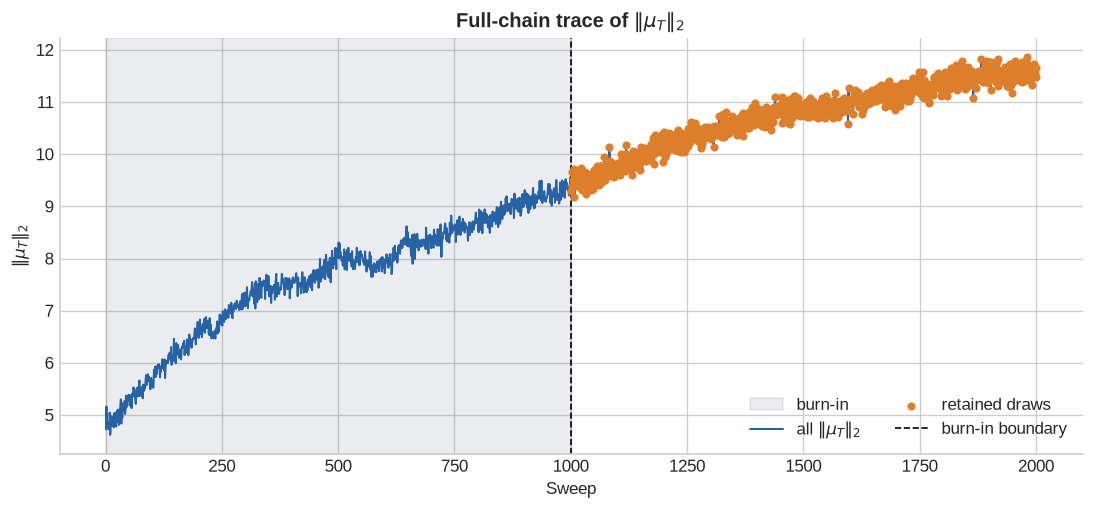

In [4]:
mu_norm = np.linalg.norm(mu_all.reshape(len(mu_all), -1), axis=1)
post_mask = sweeps > config["burn_in"]
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.axvspan(sweeps[0], config["burn_in"], color=COLORS["gray"], alpha=.13,
           label="burn-in")
ax.plot(sweeps, mu_norm, color=COLORS["blue"], lw=1.2, label=r"all $\|\mu_T\|_2$")
retained_norm = np.linalg.norm(mu_retained.reshape(len(mu_retained), -1), axis=1)
ax.scatter(retained_sweeps, retained_norm, s=15, color=COLORS["orange"], zorder=3,
           label="retained draws")
ax.axvline(config["burn_in"], color="black", ls="--", lw=1, label="burn-in boundary")
ax.set(xlabel="Sweep", ylabel=r"$\|\mu_T\|_2$", title=r"Full-chain trace of $\|\mu_T\|_2$")
ax.legend(ncol=2, frameon=False); plt.show()
first_half, second_half = np.array_split(mu_norm[post_mask], 2)
norm_slope = np.polyfit(sweeps[post_mask], mu_norm[post_mask], 1)[0]

In [5]:
display(Markdown(f'''
1. **What this plot shows:** the global magnitude of the 784-dimensional
   terminal mean at every saved sweep. Burn-in is shaded; orange points are the
   {len(mu_retained)} retained draws.
2. **What a healthy trace would roughly look like:** after transient behavior,
   it should move repeatedly through a stable range without persistent drift or
   long periods of near-constant values.
3. **What we observe:** the post-burn-in first- and second-half means are
   `{first_half.mean():.3f}` and `{second_half.mean():.3f}`; the fitted
   post-burn-in slope is `{norm_slope:.4g}` norm units per sweep. The trace is
   visibly smooth, so serial dependence must be quantified rather than inferred
   from its range alone.
4. **What I should tell my professor:** the norm remains finite and bounded in
   the retained region, but the slow movement suggests that {len(mu_retained)} retained draws
   may represent fewer independent draws because of serial correlation.
5. **Caveat:** one scalar norm can conceal compensating movement among pixels,
   and visual stability alone is not evidence of convergence.
'''))


1. **What this plot shows:** the global magnitude of the 784-dimensional
   terminal mean at every saved sweep. Burn-in is shaded; orange points are the
   1000 retained draws.
2. **What a healthy trace would roughly look like:** after transient behavior,
   it should move repeatedly through a stable range without persistent drift or
   long periods of near-constant values.
3. **What we observe:** the post-burn-in first- and second-half means are
   `10.250` and `11.254`; the fitted
   post-burn-in slope is `0.002101` norm units per sweep. The trace is
   visibly smooth, so serial dependence must be quantified rather than inferred
   from its range alone.
4. **What I should tell my professor:** the norm remains finite and bounded in
   the retained region, but the slow movement suggests that 1000 retained draws
   may represent fewer independent draws because of serial correlation.
5. **Caveat:** one scalar norm can conceal compensating movement among pixels,
   and visual stability alone is not evidence of convergence.


## 4. Traces for selected $\mu_T$ coordinates

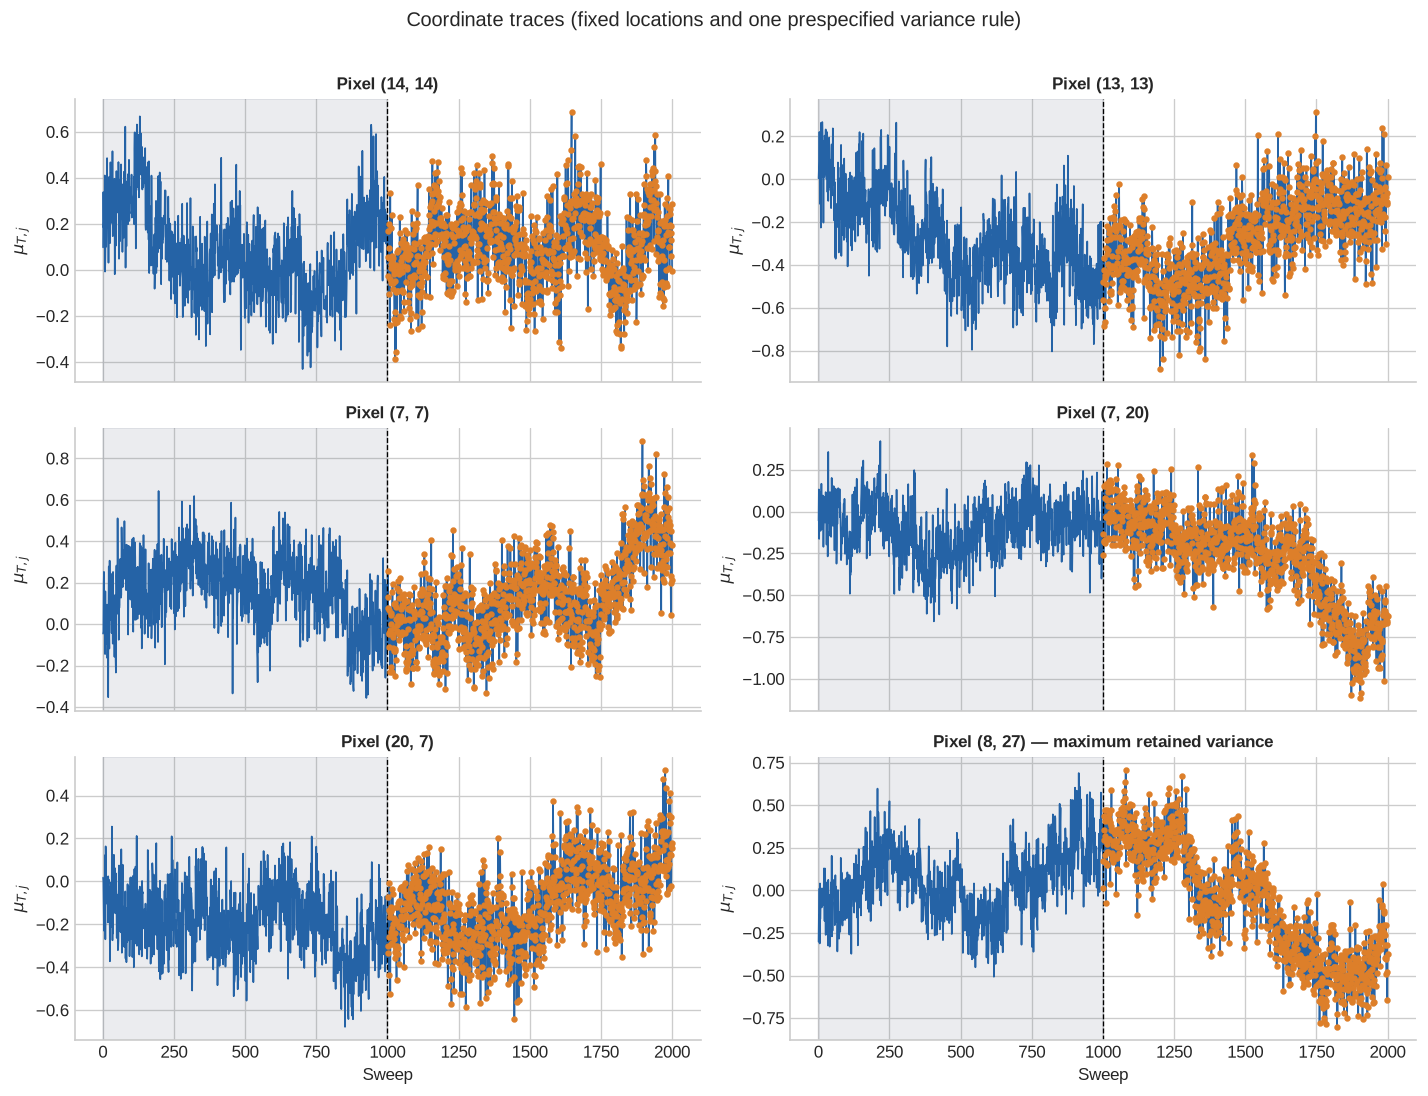

In [6]:
# Fixed geometric coordinates plus one deterministic maximum-variance coordinate.
posterior_sd = mu_retained[..., 0].astype(np.float64).std(axis=0, ddof=1)
fixed_coords = [(14, 14), (13, 13), (7, 7), (7, 20), (20, 7)]
max_variance_coord = tuple(int(x) for x in np.unravel_index(np.argmax(posterior_sd),
                                                            posterior_sd.shape))
selected_coords = fixed_coords + ([max_variance_coord] if max_variance_coord not in fixed_coords else [])

fig, axes = plt.subplots(3, 2, figsize=(12, 9), sharex=True)
for ax, (row, col) in zip(axes.flat, selected_coords):
    values = mu_all[:, row, col, 0]
    ax.axvspan(1, config["burn_in"], color=COLORS["gray"], alpha=.13)
    ax.plot(sweeps, values, color=COLORS["blue"], lw=1)
    ax.scatter(retained_sweeps, mu_retained[:, row, col, 0], s=8,
               color=COLORS["orange"], zorder=3)
    ax.axvline(config["burn_in"], color="black", ls="--", lw=.8)
    suffix = " — maximum retained variance" if (row, col) == max_variance_coord else ""
    ax.set_title(f"Pixel ({row}, {col}){suffix}", fontsize=10)
    ax.set_ylabel(r"$\mu_{T,j}$")
for ax in axes[-1]: ax.set_xlabel("Sweep")
fig.suptitle(r"Coordinate traces (fixed locations and one prespecified variance rule)", y=1.01)
fig.tight_layout(); plt.show()

In [7]:
display(Markdown(f'''
**Why this matters.** $\|\mu_T\|_2$ compresses all 784 coordinates and can look
stable even when individual pixels drift or mix slowly. Coordinate traces reveal
local persistence. Five locations were fixed geometrically; pixel
`{max_variance_coord}` was added by the deterministic rule “largest retained
posterior variance,” rather than by choosing an attractive trace.

**What I should tell my professor.** Mixing is heterogeneous across pixels. Some
coordinates move rapidly while the maximum-variance coordinate shows much
stronger persistence. This reinforces that a global norm alone is insufficient.

**Limitation.** Six traces cannot represent all 784 coordinates, and the
maximum-variance coordinate was identified from this same completed chain.
'''))


**Why this matters.** $\|\mu_T\|_2$ compresses all 784 coordinates and can look
stable even when individual pixels drift or mix slowly. Coordinate traces reveal
local persistence. Five locations were fixed geometrically; pixel
`(8, 27)` was added by the deterministic rule “largest retained
posterior variance,” rather than by choosing an attractive trace.

**What I should tell my professor.** Mixing is heterogeneous across pixels. Some
coordinates move rapidly while the maximum-variance coordinate shows much
stronger persistence. This reinforces that a global norm alone is insufficient.

**Limitation.** Six traces cannot represent all 784 coordinates, and the
maximum-variance coordinate was identified from this same completed chain.


## 5. Autocorrelation and effective sample size

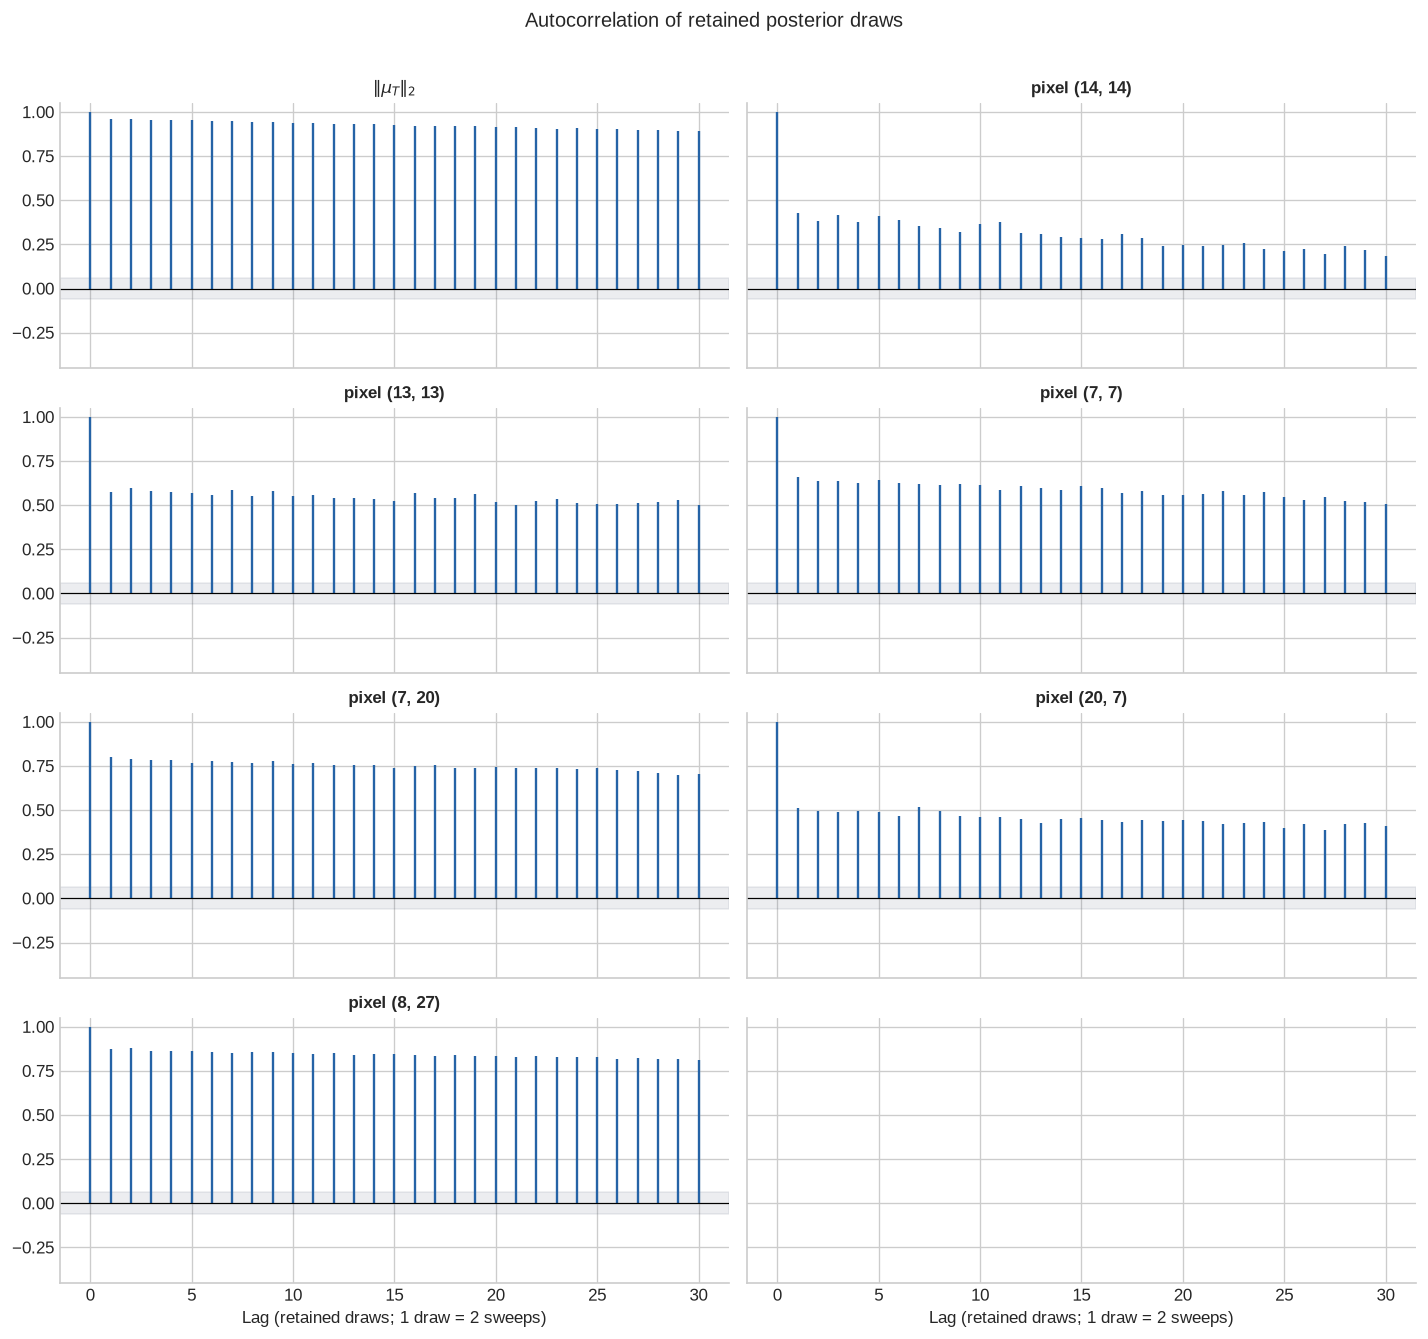

Quantity,Retained draws,Estimated ESS,ESS / draws
$\|\mu_T\|_2$,1000,2.83,0.003
"pixel (14, 14)",1000,38.14,0.038
"pixel (13, 13)",1000,4.79,0.005
"pixel (7, 7)",1000,9.27,0.009
"pixel (7, 20)",1000,4.52,0.005
"pixel (20, 7)",1000,8.23,0.008
"pixel (8, 27)",1000,3.11,0.003


In [8]:
def autocorrelation(values):
    # Biased-normalized ACF for a transparent short-chain diagnostic.
    x = np.asarray(values, dtype=np.float64)
    x = x - x.mean()
    if np.allclose(x, 0):
        return np.r_[1.0, np.zeros(len(x) - 1)]
    covariance = np.correlate(x, x, mode="full")[len(x)-1:]
    covariance /= np.arange(len(x), 0, -1)
    return covariance / covariance[0]

def initial_positive_sequence_ess(values):
    # Geyer-style initial-positive-pair ESS, capped at the number of draws.
    acf = autocorrelation(values)
    positive_pairs = []
    for lag in range(1, len(acf) - 1, 2):
        pair = acf[lag] + acf[lag + 1]
        if pair <= 0:
            break
        positive_pairs.append(pair)
    tau = 1 + 2 * np.sum(positive_pairs)
    return min(float(len(values)), float(len(values) / tau))

series = {r"$\|\mu_T\|_2$": retained_norm}
for row, col in selected_coords:
    series[f"pixel ({row}, {col})"] = mu_retained[:, row, col, 0]

max_lag = min(30, len(mu_retained) - 1)
fig, axes = plt.subplots(4, 2, figsize=(12, 11), sharex=True, sharey=True)
for ax, (label, values) in zip(axes.flat, series.items()):
    acf = autocorrelation(values)[:max_lag + 1]
    ax.vlines(np.arange(len(acf)), 0, acf, color=COLORS["blue"], lw=1.4)
    ax.axhline(0, color="black", lw=.7)
    ax.axhspan(-1.96 / np.sqrt(len(values)), 1.96 / np.sqrt(len(values)),
               color=COLORS["gray"], alpha=.12)
    ax.set_title(label, fontsize=10); ax.set_ylim(-.45, 1.05)
for ax in axes[-1]: ax.set_xlabel("Lag (retained draws; 1 draw = 2 sweeps)")
fig.suptitle("Autocorrelation of retained posterior draws", y=1.01)
fig.tight_layout(); plt.show()

ess_rows = []
for label, values in series.items():
    ess = initial_positive_sequence_ess(values)
    ess_rows.append((label, len(values), f"{ess:.2f}", f"{ess/len(values):.3f}"))
table(ess_rows, ("Quantity", "Retained draws", "Estimated ESS", "ESS / draws"))
selected_ess = np.array([initial_positive_sequence_ess(v) for v in series.values()])

In [9]:
display(Markdown(f'''
**What this tells us.** MCMC draws are correlated, so {len(mu_retained)} retained samples do
not necessarily equal {len(mu_retained)} independent samples. Using the transparent
initial-positive-pair estimator, selected ESS values range from
**{selected_ess.min():.1f} to {selected_ess.max():.1f}**, with mean
**{selected_ess.mean():.1f}**. The norm ESS is
**{initial_positive_sequence_ess(retained_norm):.1f}**, which is low.

**What I should tell my professor.** This is a completed longer single chain. The low ESS values show that substantial serial dependence remains despite
the longer run. Additional chain length or improved latent-state updates should be considered,
especially for global magnitude and the highest-variance coordinate.

Only one chain was run, so ordinary multi-chain $\hat R$ is unavailable and is
not reported. We do not manufacture chains by reshaping this one. Single-chain ESS estimates remain approximate and cannot replace
independent-chain convergence checks.
'''))


**What this tells us.** MCMC draws are correlated, so 1000 retained samples do
not necessarily equal 1000 independent samples. Using the transparent
initial-positive-pair estimator, selected ESS values range from
**2.8 to 38.1**, with mean
**10.1**. The norm ESS is
**2.8**, which is low.

**What I should tell my professor.** This is a completed longer single chain. The low ESS values show that substantial serial dependence remains despite
the longer run. Additional chain length or improved latent-state updates should be considered,
especially for global magnitude and the highest-variance coordinate.

Only one chain was run, so ordinary multi-chain $\hat R$ is unavailable and is
not reported. We do not manufacture chains by reshaping this one. Single-chain ESS estimates remain approximate and cannot replace
independent-chain convergence checks.


## 6. MALA acceptance rate by diffusion time

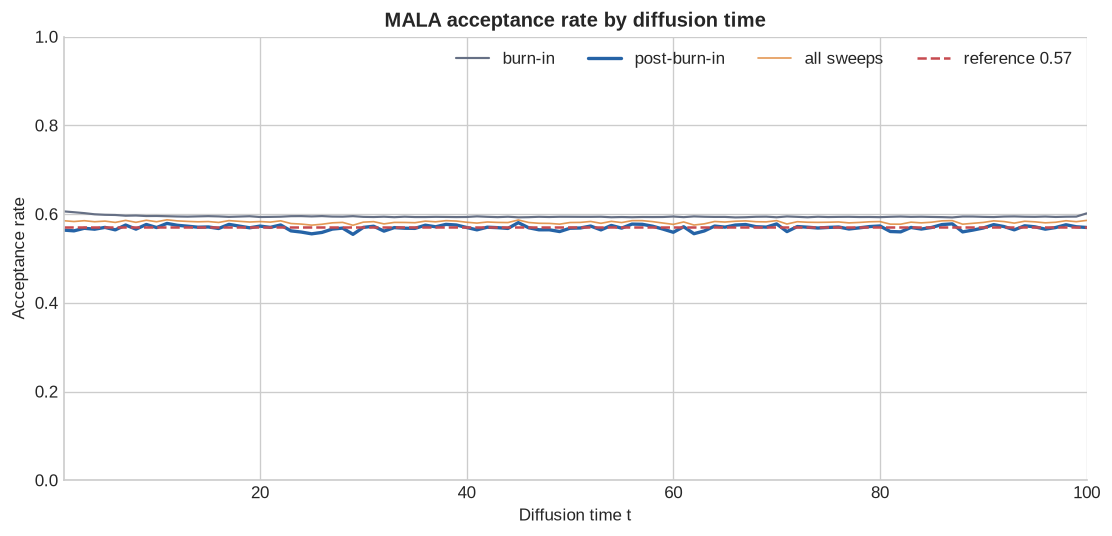

Post-burn-in summary,Value
Minimum,0.554
Median,0.570
Mean,0.569
Maximum,0.581
Five lowest times,"[29, 25, 62, 26, 60]"
Five highest times,"[45, 11, 87, 70, 56]"


In [10]:
T = config["T"]; n = config["n"]; burn = config["burn_in"]
t = np.arange(1, T + 1)
accept_all = diagnostics["acceptance_rates"]
accept_burn = diagnostics["acceptance_history"][:burn].sum(axis=0) / (burn * n)
post_sweeps = config["total_sweeps"] - burn
accept_post = diagnostics["post_burn_in_accepted"] / (post_sweeps * n)

fig, ax = plt.subplots(figsize=(11, 4.8))
ax.plot(t, accept_burn, label="burn-in", color=COLORS["gray"], lw=1.3)
ax.plot(t, accept_post, label="post-burn-in", color=COLORS["blue"], lw=2)
ax.plot(t, accept_all, label="all sweeps", color=COLORS["orange"], lw=1, alpha=.8)
ax.axhline(config["target_acceptance"], color=COLORS["red"], ls="--",
           label=f"reference {config['target_acceptance']:.2f}")
ax.set(xlabel="Diffusion time t", ylabel="Acceptance rate",
       title="MALA acceptance rate by diffusion time", xlim=(1, T), ylim=(0, 1))
ax.legend(frameon=False, ncol=4); plt.show()

low_times = (np.argsort(accept_post)[:5] + 1).tolist()
high_times = (np.argsort(accept_post)[-5:][::-1] + 1).tolist()
table([
    ("Minimum", f"{accept_post.min():.3f}"),
    ("Median", f"{np.median(accept_post):.3f}"),
    ("Mean", f"{accept_post.mean():.3f}"),
    ("Maximum", f"{accept_post.max():.3f}"),
    ("Five lowest times", str(low_times)),
    ("Five highest times", str(high_times)),
], ("Post-burn-in summary", "Value"))

In [11]:
display(Markdown(f'''
MALA acceptance is a tuning diagnostic. Very high acceptance can mean proposals
are too small; very low acceptance can mean they are too aggressive. The common
0.57 value is an asymptotic reference, not a universal pass/fail threshold.

### What I should tell my professor

Post-burn-in rates range from **{accept_post.min():.3f} to
{accept_post.max():.3f}**, with mean **{accept_post.mean():.3f}** and median
**{np.median(accept_post):.3f}**. Adaptation therefore centered acceptance close
to the requested 0.57 reference across diffusion time. This indicates that the
accept/reject tuning behaved as designed; it does not override the low ESS seen
for some summaries or establish convergence.
'''))


MALA acceptance is a tuning diagnostic. Very high acceptance can mean proposals
are too small; very low acceptance can mean they are too aggressive. The common
0.57 value is an asymptotic reference, not a universal pass/fail threshold.

### What I should tell my professor

Post-burn-in rates range from **0.554 to
0.581**, with mean **0.569** and median
**0.570**. Adaptation therefore centered acceptance close
to the requested 0.57 reference across diffusion time. This indicates that the
accept/reject tuning behaved as designed; it does not override the low ESS seen
for some summaries or establish convergence.


## 7. MALA step size by diffusion time

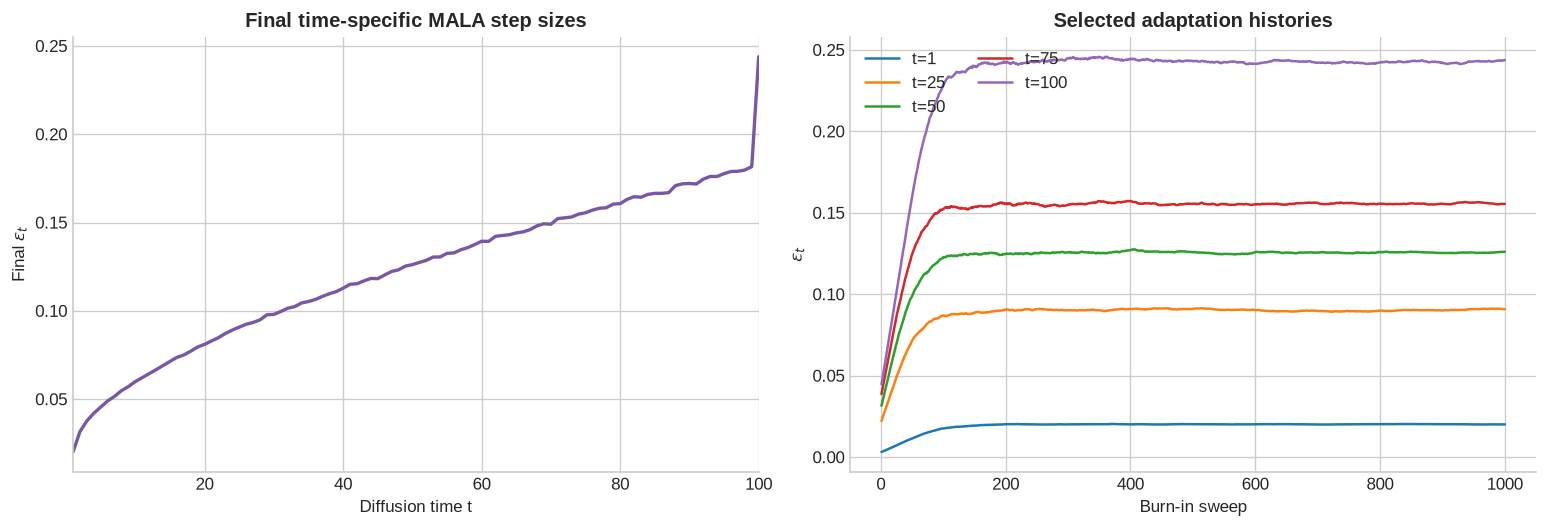

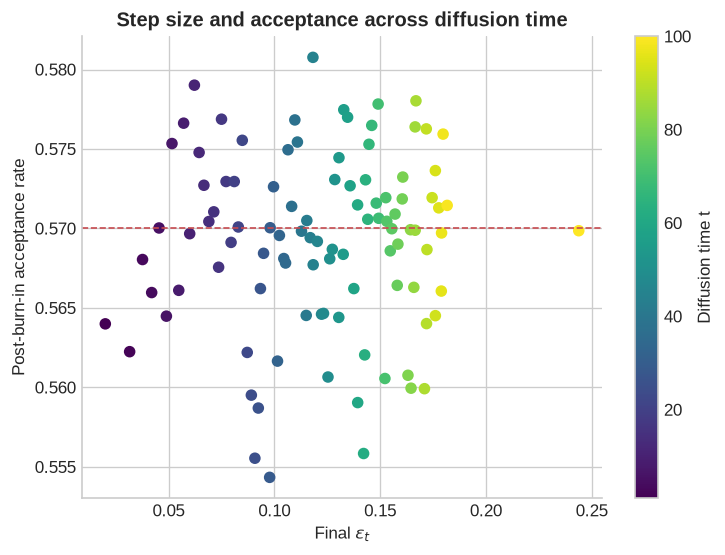

In [12]:
final_epsilon = diagnostics["final_epsilons"]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(t, final_epsilon, color=COLORS["purple"], lw=2)
axes[0].set(xlabel="Diffusion time t", ylabel=r"Final $\epsilon_t$",
            title="Final time-specific MALA step sizes", xlim=(1, T))
representative_times = [1, 25, 50, 75, 100]
for time_index in representative_times:
    axes[1].plot(np.arange(1, burn + 1),
                 diagnostics["epsilon_history"][:burn, time_index - 1],
                 label=f"t={time_index}")
axes[1].set(xlabel="Burn-in sweep", ylabel=r"$\epsilon_t$",
            title="Selected adaptation histories")
axes[1].legend(frameon=False, ncol=2)
fig.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(7, 5))
points = ax.scatter(final_epsilon, accept_post, c=t, cmap="viridis", s=35)
ax.axhline(config["target_acceptance"], color=COLORS["red"], ls="--", lw=1)
ax.set(xlabel=r"Final $\epsilon_t$", ylabel="Post-burn-in acceptance rate",
       title="Step size and acceptance across diffusion time")
fig.colorbar(points, ax=ax, label="Diffusion time t"); plt.show()

Separate step sizes are used because the conditional geometry changes strongly
with noise level (t). Burn-in adaptation changed each (epsilon_t) according
to its own acceptance rate and then froze the vector for retained sampling. The
increasing scale across (t) is therefore expected to interact with the changing
diffusion variance; step sizes should not be compared without that context.

**What I should tell my professor.** Time-specific adaptation produced a smooth
step-size profile and similar post-burn-in acceptance rates across time. The
remaining serial dependence suggests that acceptance near 0.57 alone is not a
complete tuning criterion; blocked updates or longer runs may still help.

## 8. Posterior mean of $\mu_T$

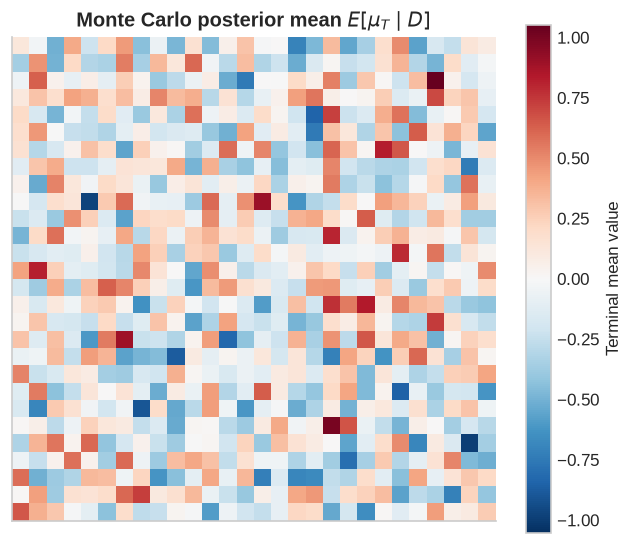

Quantity,Value
L2 norm,9.427306
Minimum pixel,-0.994518
Maximum pixel,1.052981
Mean pixel,-0.007548


In [13]:
posterior_mean = mu_retained.astype(np.float64).mean(axis=0)[..., 0]
mean_stats = {
    "L2 norm": np.linalg.norm(posterior_mean), "Minimum pixel": posterior_mean.min(),
    "Maximum pixel": posterior_mean.max(), "Mean pixel": posterior_mean.mean(),
}
fig, ax = plt.subplots(figsize=(6.5, 5.5))
limit = np.abs(posterior_mean).max()
image = ax.imshow(posterior_mean, cmap="RdBu_r", vmin=-limit, vmax=limit)
ax.set_title(r"Monte Carlo posterior mean $E[\mu_T\mid D]$")
ax.set(xticks=[], yticks=[]); fig.colorbar(image, ax=ax, label="Terminal mean value")
plt.show()
table([(k, f"{v:.6f}") for k, v in mean_stats.items()])

In [14]:
display(Markdown(f'''
This image estimates $E[\mu_T\mid D]$ by averaging the {len(mu_retained)} retained
draws. Its L2 norm is **{mean_stats['L2 norm']:.3f}**, and pixel values range from
**{mean_stats['Minimum pixel']:.3f} to {mean_stats['Maximum pixel']:.3f}**.

**Crucial interpretation:** $\mu_T$ is the inferred mean of the terminal latent
distribution. It is **not** a reconstructed MNIST image and not an ordinary DDPM
sample.

### What I should tell my professor

The image shows the posterior-average spatial structure of the terminal mean
parameter under this augmented model. Any visible pattern is a feature of the
estimated terminal latent mean, and its reliability is limited by the chain's
small effective sample size.
'''))


This image estimates $E[\mu_T\mid D]$ by averaging the 1000 retained
draws. Its L2 norm is **9.427**, and pixel values range from
**-0.995 to 1.053**.

**Crucial interpretation:** $\mu_T$ is the inferred mean of the terminal latent
distribution. It is **not** a reconstructed MNIST image and not an ordinary DDPM
sample.

### What I should tell my professor

The image shows the posterior-average spatial structure of the terminal mean
parameter under this augmented model. Any visible pattern is a feature of the
estimated terminal latent mean, and its reliability is limited by the chain's
small effective sample size.


## 9. Posterior standard deviation of $\mu_T$

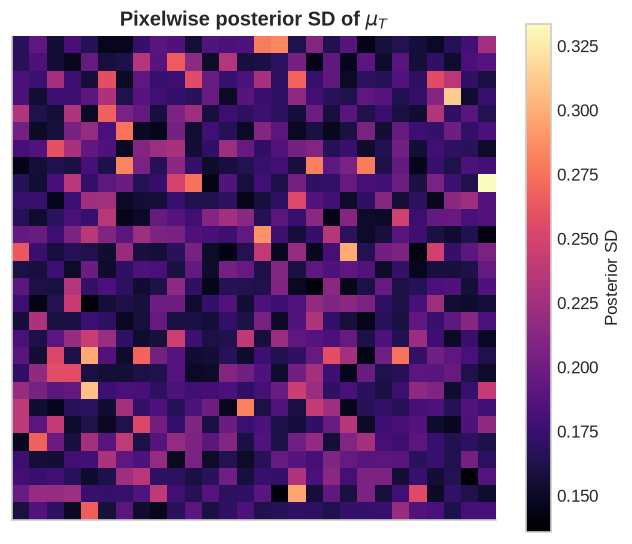

Quantity,Value
Mean coordinate SD,0.183531
Median coordinate SD,0.176078
Maximum coordinate SD,0.333657
Largest-SD coordinates,"(8, 27): 0.334, (3, 25): 0.312, (20, 4): 0.308, (12, 19): 0.298, (18, 4): 0.298, (26, 16): 0.297, (11, 14): 0.289, (0, 15): 0.284"


In [15]:
sd_flat_order = np.argsort(posterior_sd.ravel())[::-1]
largest_sd = [(tuple(int(x) for x in np.unravel_index(index, posterior_sd.shape)),
               posterior_sd.ravel()[index]) for index in sd_flat_order[:8]]
fig, ax = plt.subplots(figsize=(6.5, 5.5))
image = ax.imshow(posterior_sd, cmap="magma")
ax.set_title(r"Pixelwise posterior SD of $\mu_T$")
ax.set(xticks=[], yticks=[]); fig.colorbar(image, ax=ax, label="Posterior SD")
plt.show()
table([
    ("Mean coordinate SD", f"{posterior_sd.mean():.6f}"),
    ("Median coordinate SD", f"{np.median(posterior_sd):.6f}"),
    ("Maximum coordinate SD", f"{posterior_sd.max():.6f}"),
    ("Largest-SD coordinates", ", ".join(f"{coord}: {value:.3f}" for coord, value in largest_sd)),
])

In [16]:
display(Markdown(f'''
This map describes uncertainty in the inferred parameter $\mu_T$ across
posterior draws. The mean coordinate SD is **{posterior_sd.mean():.3f}** and the
maximum is **{posterior_sd.max():.3f}** at `{largest_sd[0][0]}`.

It is **not** $\Sigma_T$. The model fixed $\Sigma_T=I$ exactly; that covariance
describes $Y_T\mid\mu_T$. This plot instead describes posterior uncertainty in
the unknown mean parameter, $\mathrm{{SD}}(\mu_{{T,j}}\mid D)$.

### What I should tell my professor

The posterior does not estimate terminal observation variance in this completed chain. It
estimates a distribution over the terminal mean, and this map shows where that
mean is more or less uncertain—subject to Monte Carlo error and the lack of additional completed chains.
'''))


This map describes uncertainty in the inferred parameter $\mu_T$ across
posterior draws. The mean coordinate SD is **0.184** and the
maximum is **0.334** at `(8, 27)`.

It is **not** $\Sigma_T$. The model fixed $\Sigma_T=I$ exactly; that covariance
describes $Y_T\mid\mu_T$. This plot instead describes posterior uncertainty in
the unknown mean parameter, $\mathrm{SD}(\mu_{T,j}\mid D)$.

### What I should tell my professor

The posterior does not estimate terminal observation variance in this completed chain. It
estimates a distribution over the terminal mean, and this map shows where that
mean is more or less uncertain—subject to Monte Carlo error and the lack of additional completed chains.


## 10. Posterior distributions of selected coordinates

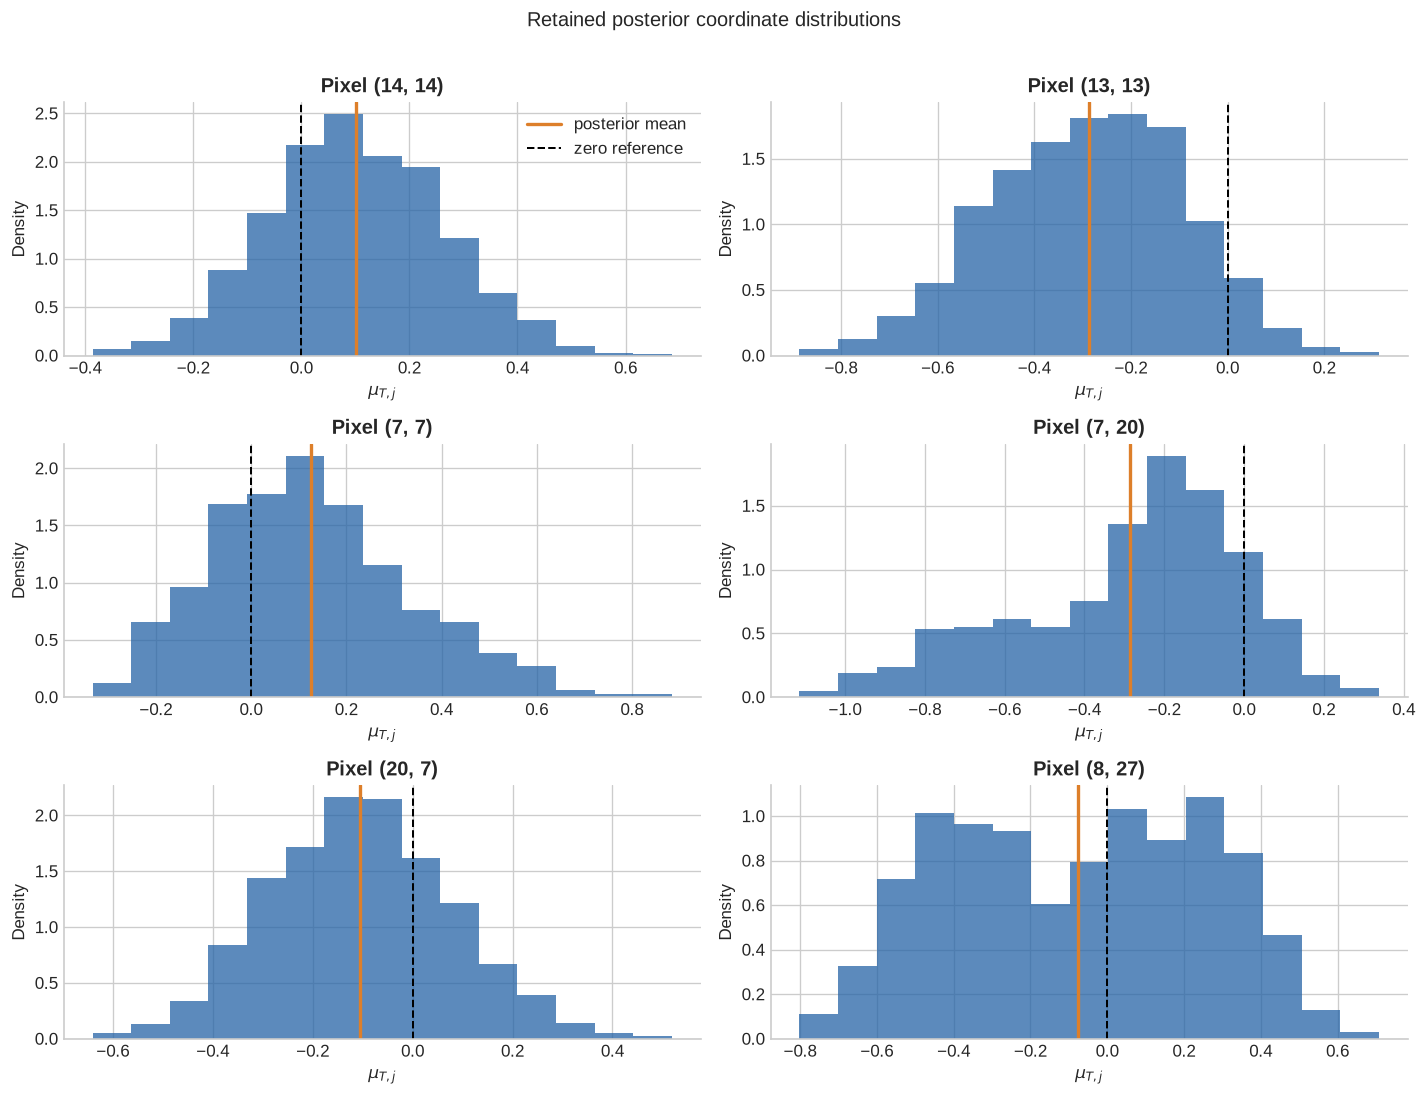

In [17]:
fig, axes = plt.subplots(3, 2, figsize=(12, 9))
for ax, (row, col) in zip(axes.flat, selected_coords):
    values = mu_retained[:, row, col, 0]
    ax.hist(values, bins=15, density=True, color=COLORS["blue"], alpha=.75)
    ax.axvline(values.mean(), color=COLORS["orange"], lw=2, label="posterior mean")
    ax.axvline(0, color="black", ls="--", lw=1.2, label="zero reference")
    ax.set_title(f"Pixel ({row}, {col})")
    ax.set_xlabel(r"$\mu_{T,j}$"); ax.set_ylabel("Density")
axes.flat[0].legend(frameon=False)
fig.suptitle("Retained posterior coordinate distributions", y=1.01)
fig.tight_layout(); plt.show()

These histograms descriptively compare selected marginal posteriors with zero,
the conventional standard-DDPM terminal mean. They can show whether this chain's
sample mass appears near or away from zero for particular coordinates.

**What I should tell my professor.** Several selected coordinates have posterior
mass displaced from zero, but this is not a formal hypothesis test. Strong
claims would require better ESS, independent chains, sensitivity analysis, and
a broader summary across coordinates.

## 11. Global deviation of $\mu_T$ from zero

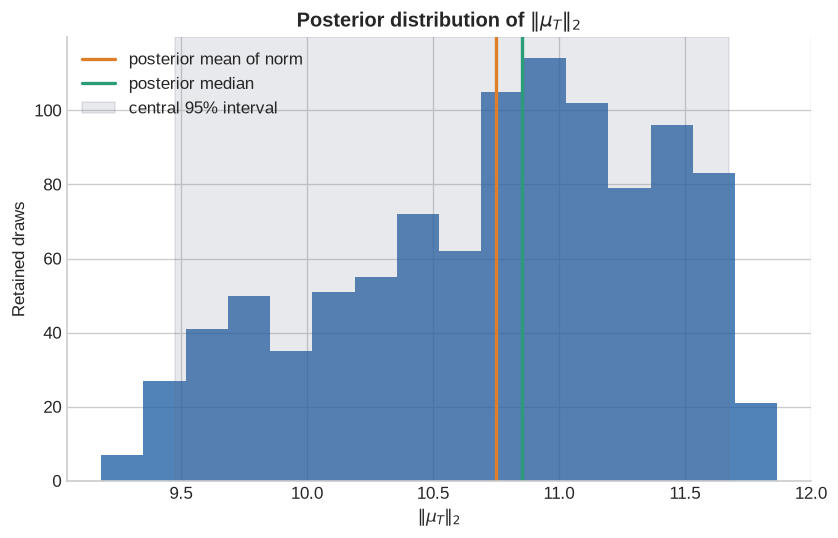

Quantity,Value
Posterior mean norm,10.751748
Posterior median norm,10.852451
2.5% posterior quantile,9.478167
97.5% posterior quantile,11.676531
Norm of posterior mean,9.427306


In [18]:
norm_summary = {
    "Posterior mean norm": retained_norm.mean(),
    "Posterior median norm": np.median(retained_norm),
    "2.5% posterior quantile": np.quantile(retained_norm, .025),
    "97.5% posterior quantile": np.quantile(retained_norm, .975),
    "Norm of posterior mean": np.linalg.norm(posterior_mean),
}
fig, ax = plt.subplots(figsize=(8, 4.8))
ax.hist(retained_norm, bins=16, color=COLORS["blue"], alpha=.8)
ax.axvline(norm_summary["Posterior mean norm"], color=COLORS["orange"], lw=2,
           label="posterior mean of norm")
ax.axvline(norm_summary["Posterior median norm"], color=COLORS["green"], lw=2,
           label="posterior median")
ax.axvspan(norm_summary["2.5% posterior quantile"], norm_summary["97.5% posterior quantile"],
           color=COLORS["gray"], alpha=.15, label="central 95% interval")
ax.set(xlabel=r"$\|\mu_T\|_2$", ylabel="Retained draws",
       title=r"Posterior distribution of $\|\mu_T\|_2$")
ax.legend(frameon=False); plt.show()
table([(name, f"{value:.6f}") for name, value in norm_summary.items()])

In [19]:
display(Markdown(f'''
The standard DDPM terminal reference is centered at zero. Here the retained norm
has posterior mean **{norm_summary['Posterior mean norm']:.3f}**, median
**{norm_summary['Posterior median norm']:.3f}**, and central 95% interval
**[{norm_summary['2.5% posterior quantile']:.3f},
{norm_summary['97.5% posterior quantile']:.3f}]**. The norm of the posterior mean
is **{norm_summary['Norm of posterior mean']:.3f}**.

### What I should tell my professor

This completed chain suggests a nonzero terminal mean under this fitted augmented model.
It does not prove that the standard $N(0,I)$ terminal approximation is wrong.
Finite $T$, Stage-1 model quality, misspecification, the data split, and the limitations of single-chain MCMC
all affect this result.
'''))


The standard DDPM terminal reference is centered at zero. Here the retained norm
has posterior mean **10.752**, median
**10.852**, and central 95% interval
**[9.478,
11.677]**. The norm of the posterior mean
is **9.427**.

### What I should tell my professor

This completed chain suggests a nonzero terminal mean under this fitted augmented model.
It does not prove that the standard $N(0,I)$ terminal approximation is wrong.
Finite $T$, Stage-1 model quality, misspecification, the data split, and the limitations of single-chain MCMC
all affect this result.


## 12. Exploratory view of the final terminal latent states $Y_T$

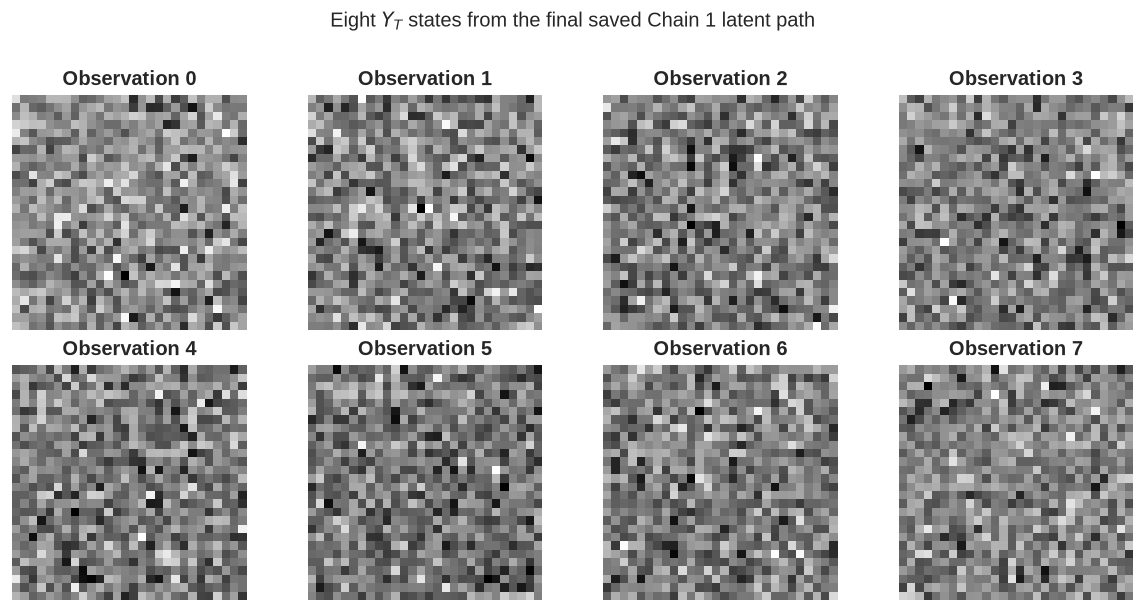

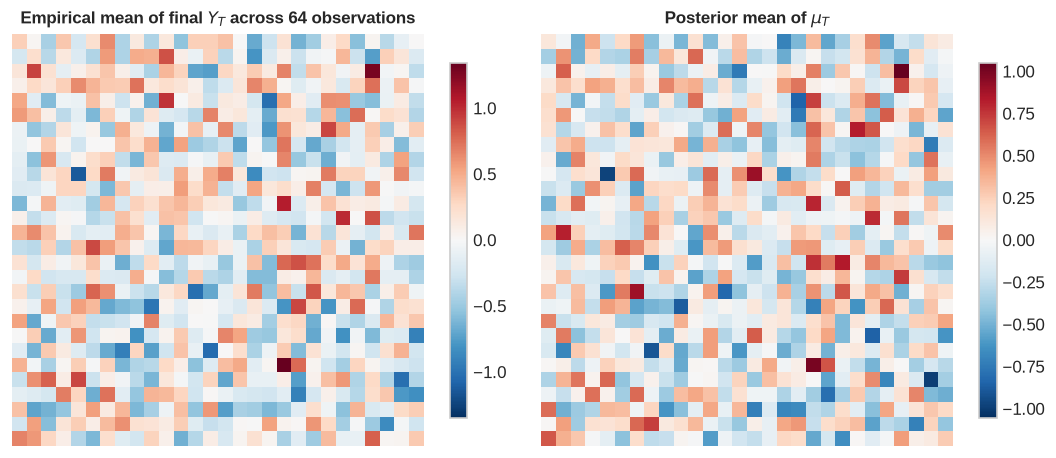

In [20]:
# Resolve the saved absolute checkpoint path portably after a directory copy.
final_checkpoint = CHAIN / "checkpoints" / Path(completion["final_chain_checkpoint"]).name
with np.load(final_checkpoint, allow_pickle=False) as checkpoint:
    final_y_t = checkpoint["paths"][-1].copy()
assert final_y_t.shape == (config["n"], 28, 28, 1)

fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for index, ax in enumerate(axes.flat):
    image = ax.imshow(final_y_t[index, ..., 0], cmap="gray")
    ax.set_title(f"Observation {index}"); ax.axis("off")
fig.suptitle(r"Eight $Y_T$ states from the final saved Chain 1 latent path", y=1.01)
fig.tight_layout(); plt.show()

final_y_t_mean = np.asarray(final_y_t, dtype=np.float64).mean(axis=0)[..., 0]
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, image, title in zip(axes, [final_y_t_mean, posterior_mean],
                            [rf"Empirical mean of final $Y_T$ across {config['n']} observations",
                             r"Posterior mean of $\mu_T$"]):
    limit = np.abs(image).max()
    plot = ax.imshow(image, cmap="RdBu_r", vmin=-limit, vmax=limit)
    ax.set_title(title, fontsize=10); ax.axis("off"); fig.colorbar(plot, ax=ax, shrink=.8)
fig.tight_layout(); plt.show()

The Gibbs update for (mu_T) depends directly on the terminal latent states, so
(Y_T) provides useful context. This section uses only the 64 terminal states
from the final checkpoint; it does not load full latent paths or multiple
checkpoints.

**What I should tell my professor.** The final empirical (Y_T) mean and the
posterior (mu_T) mean are related through the conjugate update, but one final
snapshot is exploratory. Comparing empirical (Y_T) variance with the fixed
(Sigma_T=I) would require more careful posterior predictive diagnostics.

## 13. Stage-1 sanity check

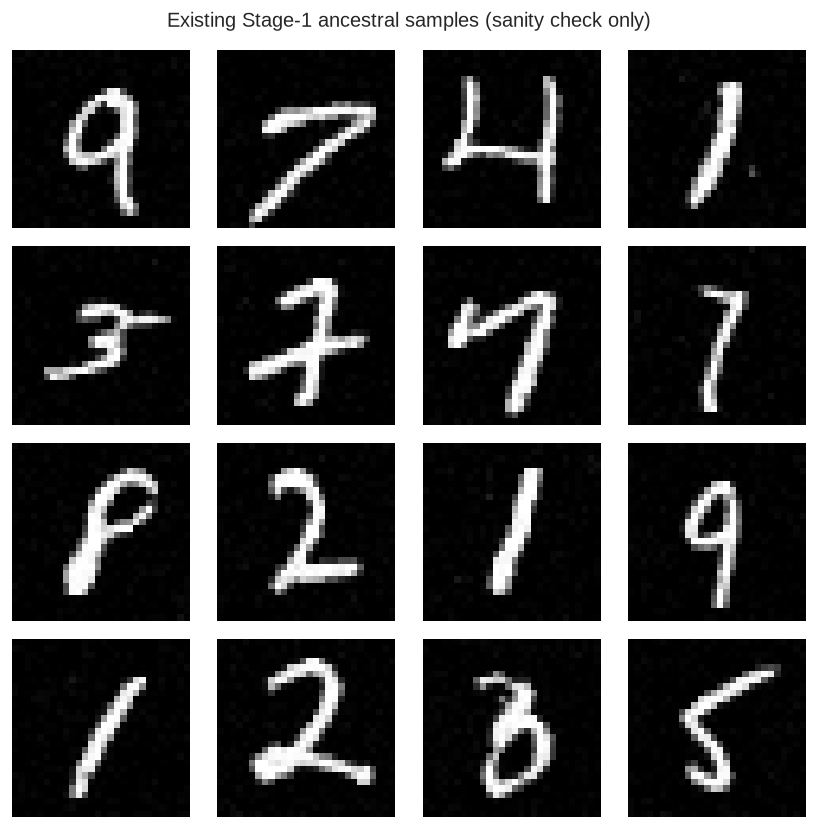

In [21]:
stage1_samples = np.load(RUN / "stage1" / "final_ancestral_smoke.npy", mmap_mode="r")
fig, axes = plt.subplots(4, 4, figsize=(7, 7))
for sample, ax in zip(stage1_samples, axes.flat):
    ax.imshow(np.clip((sample[..., 0] + 1) / 2, 0, 1), cmap="gray", vmin=0, vmax=1)
    ax.axis("off")
fig.suptitle("Existing Stage-1 ancestral samples (sanity check only)")
fig.tight_layout(); plt.show()

These samples were generated and saved when Stage 1 completed. No new sampling
was performed for this notebook. They only check that the frozen reverse model
produced recognizable outputs before Stage 2; they are not Stage-2 posterior
results and are not a scientific quality evaluation.

## 14. Summary table for the meeting

In [22]:
summary_rows = [
    ("Total sweeps", config["total_sweeps"]),
    ("Burn-in", config["burn_in"]),
    ("Thinning", config["thinning"]),
    ("Retained draws", len(mu_retained)),
    (r"Posterior mean ||mu_T||", f"{retained_norm.mean():.4f}"),
    (r"Posterior median ||mu_T||", f"{np.median(retained_norm):.4f}"),
    (r"95% interval for ||mu_T||",
     f"[{np.quantile(retained_norm,.025):.4f}, {np.quantile(retained_norm,.975):.4f}]"),
    ("Mean posterior coordinate SD", f"{posterior_sd.mean():.4f}"),
    ("Median posterior coordinate SD", f"{np.median(posterior_sd):.4f}"),
    ("Minimum post-burn-in acceptance", f"{accept_post.min():.4f}"),
    ("Median post-burn-in acceptance", f"{np.median(accept_post):.4f}"),
    ("Maximum post-burn-in acceptance", f"{accept_post.max():.4f}"),
    ("Mean selected ESS", f"{selected_ess.mean():.2f}"),
    ("Minimum selected ESS", f"{selected_ess.min():.2f}"),
    ("Any saved NaN/Inf", "No" if all(p for _,_,p in checks[5:9]) else "Yes"),
]
table(summary_rows)

Quantity,Value
Total sweeps,2000
Burn-in,1000
Thinning,1
Retained draws,1000
Posterior mean ||mu_T||,10.7517
Posterior median ||mu_T||,10.8525
95% interval for ||mu_T||,"[9.4782, 11.6765]"
Mean posterior coordinate SD,0.1835
Median posterior coordinate SD,0.1761
Minimum post-burn-in acceptance,0.5543


## What I would tell my professor

In [23]:
display(Markdown(f'''
I trained the unconditional Stage-1 DDPM on a separate half of MNIST, froze its
learned reverse model, and used 64 observations from the other half for Stage-2
posterior inference. Directly targeting $p(\mu_T\mid D)$ requires integrating
over all latent diffusion paths, so I targeted the augmented posterior
$p(\mu_T,Z\mid D)$ instead. I updated $\mu_T$ exactly with its conjugate Gaussian
Gibbs step and updated the latent states with time-specific MALA proposals and
the full Metropolis–Hastings correction.

This completed single-chain run used **{config["total_sweeps"]} sweeps**,
with **{config["burn_in"]} burn-in sweeps**, thinning
**{config["thinning"]}**, and **{len(mu_retained)} retained $\mu_T$ draws**. All saved posterior values, acceptance
statistics, step sizes, and gradient diagnostics were finite, and the run
recorded that the Stage-1 parameters remained unchanged. Post-burn-in acceptance
was well balanced across diffusion time—mean **{accept_post.mean():.3f}**, range
**[{accept_post.min():.3f}, {accept_post.max():.3f}]**—and close to the 0.57
tuning reference.

The more important limitation is serial dependence. Selected ESS estimates
range from **{selected_ess.min():.1f} to {selected_ess.max():.1f}**, and the norm
ESS is only **{initial_positive_sequence_ess(retained_norm):.1f}**. Thus I would
not claim convergence from this single chain. The retained posterior suggests a
nonzero terminal mean: the norm has median **{np.median(retained_norm):.3f}** and
central 95% interval **[{np.quantile(retained_norm,.025):.3f},
{np.quantile(retained_norm,.975):.3f}]**; the norm of the posterior mean is
**{np.linalg.norm(posterior_mean):.3f}**. Mean pixelwise posterior SD is
**{posterior_sd.mean():.3f}**. These are properties of the terminal mean
parameter, not generated digit images and not estimates of $\Sigma_T$, which was
fixed to identity.

The next study should prioritize multiple completed independent chains, then
consider a larger Stage-2 sample, tuning or blocked latent updates if persistence
continues, sensitivity to $\\tau_\mu$, and eventually a structured unknown
$\Sigma_T$. Only after those checks would I make a stronger comparison with the
standard $N(0,I)$ terminal assumption.
'''))


I trained the unconditional Stage-1 DDPM on a separate half of MNIST, froze its
learned reverse model, and used 64 observations from the other half for Stage-2
posterior inference. Directly targeting $p(\mu_T\mid D)$ requires integrating
over all latent diffusion paths, so I targeted the augmented posterior
$p(\mu_T,Z\mid D)$ instead. I updated $\mu_T$ exactly with its conjugate Gaussian
Gibbs step and updated the latent states with time-specific MALA proposals and
the full Metropolis–Hastings correction.

This completed single-chain run used **2000 sweeps**,
with **1000 burn-in sweeps**, thinning
**1**, and **1000 retained $\mu_T$ draws**. All saved posterior values, acceptance
statistics, step sizes, and gradient diagnostics were finite, and the run
recorded that the Stage-1 parameters remained unchanged. Post-burn-in acceptance
was well balanced across diffusion time—mean **0.569**, range
**[0.554, 0.581]**—and close to the 0.57
tuning reference.

The more important limitation is serial dependence. Selected ESS estimates
range from **2.8 to 38.1**, and the norm
ESS is only **2.8**. Thus I would
not claim convergence from this single chain. The retained posterior suggests a
nonzero terminal mean: the norm has median **10.852** and
central 95% interval **[9.478,
11.677]**; the norm of the posterior mean is
**9.427**. Mean pixelwise posterior SD is
**0.184**. These are properties of the terminal mean
parameter, not generated digit images and not estimates of $\Sigma_T$, which was
fixed to identity.

The next study should prioritize multiple completed independent chains, then
consider a larger Stage-2 sample, tuning or blocked latent updates if persistence
continues, sensitivity to $\tau_\mu$, and eventually a structured unknown
$\Sigma_T$. Only after those checks would I make a stronger comparison with the
standard $N(0,I)$ terminal assumption.


## Questions for my professor

In [24]:
display(Markdown(f'''
1. Is the interpretation of $\mu_T$ here correct—as a terminal-distribution
   parameter rather than an image-space reconstruction—even when its posterior
   mean has visible spatial structure?
2. Given the norm ESS of about
   **{initial_positive_sequence_ess(retained_norm):.1f}**, should the next run
   prioritize longer chains, several independent chains, or a blocked update of
   neighboring latent times?
3. Post-burn-in acceptance is close to 0.57 across $t$, yet some summaries remain
   highly autocorrelated. Should tuning target ESS per second rather than
   acceptance alone?
4. Should the next sensitivity study vary $\\tau_\mu$ before increasing the
   Stage-2 sample beyond 64 observations?
5. Should $\Sigma_T$ remain fixed to $I$ for the next experiment, or is a
   diagonal or low-rank unknown covariance the more informative extension?
6. Which convergence and posterior-predictive diagnostics would you require
   before interpreting deviation from the standard $N(0,I)$ terminal model?
'''))


1. Is the interpretation of $\mu_T$ here correct—as a terminal-distribution
   parameter rather than an image-space reconstruction—even when its posterior
   mean has visible spatial structure?
2. Given the norm ESS of about
   **2.8**, should the next run
   prioritize longer chains, several independent chains, or a blocked update of
   neighboring latent times?
3. Post-burn-in acceptance is close to 0.57 across $t$, yet some summaries remain
   highly autocorrelated. Should tuning target ESS per second rather than
   acceptance alone?
4. Should the next sensitivity study vary $\tau_\mu$ before increasing the
   Stage-2 sample beyond 64 observations?
5. Should $\Sigma_T$ remain fixed to $I$ for the next experiment, or is a
   diagonal or low-rank unknown covariance the more informative extension?
6. Which convergence and posterior-predictive diagnostics would you require
   before interpreting deviation from the standard $N(0,I)$ terminal model?


---
*Notebook generated from the completed, immutable analysis bundle. No training or MCMC code is called.*